# Architecture Comparison: Deterministic vs Probabilistic Unconstraining

This notebook evaluates the performance gains of the new **Probabilistic Virtual Capacity** architecture against the old **Deterministic** architecture, focusing on the overall WAPE.


In [1]:
import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# 1. Load Deterministic Data
files_det = glob.glob("results/unconstrained_3yr/*.parquet")
df_det = pd.concat([pd.read_parquet(f) for f in files_det], ignore_index=True)

# 2. Load Probabilistic Data
files_prob = glob.glob("results/probabilistic_unconstrained_3yr/*.parquet")
df_prob = pd.concat([pd.read_parquet(f) for f in files_prob], ignore_index=True)

df_det["Date"] = pd.to_datetime(df_det["Date"])
df_prob["Date"] = pd.to_datetime(df_prob["Date"])

print(f"Loaded {len(df_det)} rows for Deterministic")
print(f"Loaded {len(df_prob)} rows for Probabilistic")


Loaded 197280 rows for Deterministic
Loaded 197280 rows for Probabilistic


In [2]:
SEGMENTS = ["Contract", "General", "Perishable", "Express", "Spot"]
MODELS = ["Naive", "EM", "PD07", "PDXPrice07", "MoE"]

# Pre-calculate 'Total' columns for both dataframes
for model in MODELS:
    df_det[f"{model}_Total_Est_kg"] = df_det[[f"{model}_{s}_Est_kg" for s in SEGMENTS if f"{model}_{s}_Est_kg" in df_det.columns]].sum(axis=1)
    df_prob[f"{model}_Total_Est_kg"] = df_prob[[f"{model}_{s}_Est_kg" for s in SEGMENTS if f"{model}_{s}_Est_kg" in df_prob.columns]].sum(axis=1)

df_det["Oracle_Total_kg"] = df_det[[f"Oracle_{s}_kg" for s in SEGMENTS]].sum(axis=1)
df_prob["Oracle_Total_kg"] = df_prob[[f"Oracle_{s}_kg" for s in SEGMENTS]].sum(axis=1)

def calc_wape(df, model, seg):
    true_col = f"Oracle_{seg}_kg"
    est_col = f"{model}_{seg}_Est_kg"
    
    if est_col not in df.columns or true_col not in df.columns:
        return np.nan
        
    valid_mask = df[est_col].notna() & df[true_col].notna()
    if not valid_mask.any(): return np.nan
    
    # Evaluate from year 2 onwards
    min_date = df["Date"].min() + pd.Timedelta(days=365)
    df_eval = df[valid_mask & (df["Date"] >= min_date)]
    
    if len(df_eval) == 0: return np.nan
    
    y_true = df_eval[true_col].values
    y_pred = df_eval[est_col].values
    
    return (np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-6)) * 100

results = []
EVAL_SEGMENTS = SEGMENTS + ["Total"]

for model in MODELS:
    for seg in EVAL_SEGMENTS:
        wape_det = calc_wape(df_det, model, seg)
        wape_prob = calc_wape(df_prob, model, seg)
        results.append({
            "Model": model,
            "Segment": seg,
            "Deterministic_WAPE": wape_det,
            "Probabilistic_WAPE": wape_prob,
            "Improvement (pp)": wape_det - wape_prob
        })

df_res = pd.DataFrame(results)


=== Overall 'Total' WAPE Comparison ===


,Deterministic_WAPE,Probabilistic_WAPE,Improvement (pp)
Model,,,
Naive,5.23,5.23,0.00
EM,3.94,3.95,-0.01
PD07,2.94,2.91,0.03
PDXPrice07,2.91,2.88,0.03
MoE,2.90,2.88,0.03


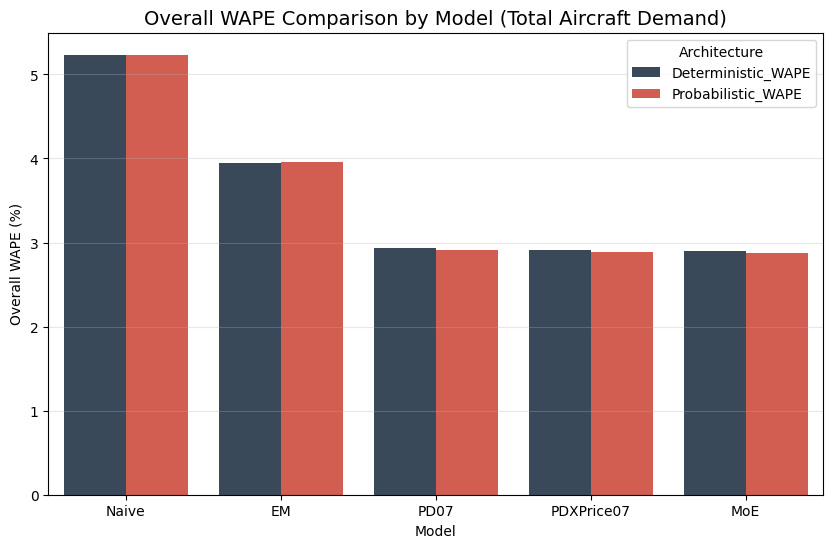

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Print full table focusing on Total
print("=== Overall 'Total' WAPE Comparison ===")
df_total = df_res[df_res["Segment"] == "Total"].set_index("Model")
display(df_total[["Deterministic_WAPE", "Probabilistic_WAPE", "Improvement (pp)"]].round(2))

df_plot = df_res[df_res["Segment"] == "Total"].melt(id_vars=["Model"], value_vars=["Deterministic_WAPE", "Probabilistic_WAPE"], 
                      var_name="Architecture", value_name="WAPE")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x="Model", y="WAPE", hue="Architecture", ci=None, palette=["#34495e", "#e74c3c"])
plt.title("Overall WAPE Comparison by Model (Total Aircraft Demand)", fontsize=14)
plt.ylabel("Overall WAPE (%)")
plt.grid(axis='y', alpha=0.3)
plt.show()


In [4]:
print("=== Segment Breakdown (for Context) ===")
display(df_res.pivot(index="Model", columns="Segment", values="Improvement (pp)").round(2))


=== Segment Breakdown (for Context) ===


Segment,Contract,Express,General,Perishable,Spot,Total
Model,,,,,,
EM,0.12,0.25,0.05,0.03,-0.61,-0.01
MoE,0.10,0.37,0.03,-0.06,-0.45,0.03
Naive,0.00,0.00,0.00,0.00,0.00,0.00
PD07,0.11,0.37,0.03,-0.06,-0.49,0.03
PDXPrice07,0.11,0.37,0.03,-0.06,-0.49,0.03
